# 군집화  

## 1. 군집화  

### 군집화의 개념과 기본 과정  
> 머신러닝 : 인공지능의 한 분야로, 컴퓨터가 스스로 학습할 수 있도록 도와주는 알고리즘이나 기술을 개발하는 분야. 크게 지도학습과 비지도학습으로 구분된다.  
- 지도 학습 : 문제와 정답을 모두 알려주고 공부시키는 방법  
- 비지도 학습 : 답을 가르쳐주지 않고 공부시키는 방법  
    | | 정답여부 | 방식 | 예시 |  
    |---|---|---|---|  
    | 지도학습 | 정답(label)이 있는 데이터 사용 | 예측값(prediction)을 이미 만들어둔 정답과 같아지도록 기계를 학습시키는 것 | 회귀, 분류 |  
    | 비지도학습 | 정답(label)이 없는 데이터 사용 | 데이터 속의 패턴 또는 각 데이터 간의 유사도를 기계가 학습하도록 하는 것 | 군집화, 연관분석 | 

> 군집화란? 데이터를 비슷한 특성을 가진 그룹(군집)으로 나누는 비지도 학습 기법  
    → 각 그룹이 어떻게 구성되어있는지 파악하면서 전체 데이터 구조를 이해할 수 있음.  
    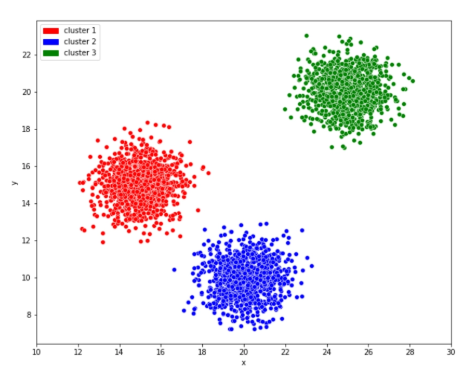  

    *군집(cluster) : 유사한 데이터들의 집합. 이때 서로 다른 군집에 속한 개체들은 비슷하지 않아야 한다*

**군집화와 지도학습의 차이**  
지도학습 : 독립변수와 종속변수 사이의 관계에서 패턴을 찾아 종속변수를 예측하고자 하는 구조  
군집화 : 종속변수를 설정하지 않고, 데이터 내부의 패턴을 인식해 유사성을 가진 그룹으로 나누는 과정  
-> 사전에 정해진 목표 없이 데이터셋에 존재하는 고유한 패턴을 발견하고 추출하기 때문에 비지도 학습으로 분류! 

- 군집화의 목표  
    - **응집도**(cohesion) 최대화 : 같은 군집에 속하는 데이터끼리는 최대한 비슷하도록 한다  
    - **분리도**(separation) 최대화 : 서로 다른 군집은 최대한 분리되도록 한다  

    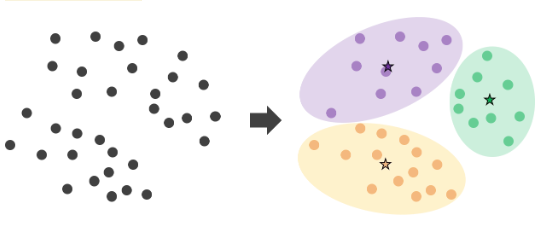  

- 군집화 과정  
1. 피처 선택 또는 추출 — 군집화에 사용할 데이터의 피처(특징)을 선택  
2. 군집화 알고리즘 선택 — 데이터의 특성과 목표에 따라 적합한 알고리즘을 선택  
3. 군집 유효성 검증 — 군집화가 얼마나 잘 되었는지 평가  
4. 결과 해석 — 각 군집이 지닌 특성 분석 및 해석  

    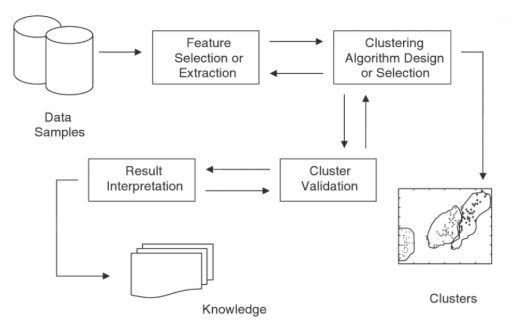

**군집화는 한번에 끝나는것이 아니라 3번 과정에서 평가해보고 마음에 안들면 다시 1번과정으로 돌아가 피처를 바꾸거나, 알고리즘을 바꾸거나 k를 바꿔서 재진행** 



## 2. 군집화를 위한 데이터 준비  

(군집화의 1번과정인 피처 선택)

**군집화의 주요 고려사항**  
1. 변수 유형 이해  
    - 군집화에 사용될 피처의 종류와 특성을 명확하게 이해해야 한다  
    - 변수 종류가 연속형 또는 명목형인지에 따라 적합한 군집화 알고리즘이 다르다  

    1. 연속형 변수(Continuous Varialbes)  
        - 특징 : 키, 몸무게, 나이, 소득 등 수치로 측정 가능한 변수  
        - 거리 측정 : 유클리디안 거리, 맨하탄 거리 등 사용 가능  
        - 적합한 알고리즘 : K-means, 계층적 군집화 등  
        *주의사항 : 스케일링 필수! (단위가 다르면 큰 값의 변수가 지배적 영향)*  
    
    2. 명목형 변수(Categorical Varialbes)  
        - 특징 : 성별, 지역, 직업 등 범주로 구분되는 변수  
        - 거리 측정 : 해밍 거리(Hamming distance), 자카드 거리 등  
        - 적합한 알고리즘 : K-modes, 계층적 군집화(특별한 거리 함수 사용)  
        - 처리 방법 : 원-핫 인코딩 또는 더미 변수 변환  

    3. 혼합형 변수(Mixed Varialbes)  
        - 특징 : 연속형과 명목형이 섞인 데이터  
        - 적합한 알고리즘 : K-prototypes, Gower distance 기반 계층적 군집화  
        - 처리 방법 : 각 변수 유형에 맞는 거리 함수를 조합하여 사용  
    **Why? 유형마다 달라지는가?**  
        변수에 따라 거리 - "삐기가 말이 되는가" / 알고리즘 - "평균이 말이 되는가" 여부가 다르기 때문에 변수 유형을 알아야 어떤 방식으로 모델링을 할지 결정할 수 있다!  



### 거리 / 유사도 정의와 측정 방법

2. 거리/유사도 정의와 측정  
    - 군집화는 데이터 간의 거리(distance) 또는 유사도(similarity)를 기반으로 그룹을 형성  
    - 변수 유형에 따라 적합한 거리 측정 방식이 다르기 때문에 정의가 중요  
    **거리 측정 방법** : 군집화에서 데이터 포인트나 군집 간의 유사성/비유사성을 수치로 계산하는 방법들. 거리가 가까울수록 유사하고, 멀수록 다르다고 판단  

    1. 유클리디안 거리(Euclidean Distance)  
        - 가장 일반적인 거리 측정 방법, 직선거리를 의미하며 k-means에서 기본적으로 사용  
        $d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}$  
    
    2. 맨하탄 거리(Manhattan Distance)  
        - 각 차원의 차이의 절댓값의 합, 이상치에 덜 민감한 특징  
        $d(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^n |x_i - y_i|$  

    *맨하탄 거리와 유클리디안 거리의 차이?*  
        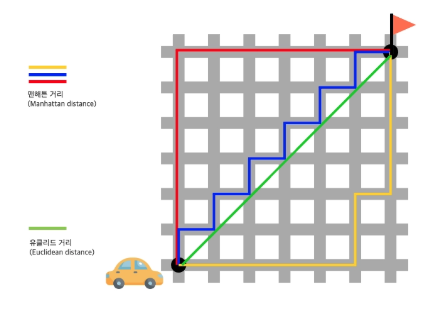  


    3. 코사인 유사도(Cosine Similarity)  
        - 벡터간의 각도 측정, 텍스트 데이터나 고차원 데이터에 효과적  
        $\text{similarity} = \frac{\mathbf{x} \cdot \mathbf{y}}{||\mathbf{x}|| \times ||\mathbf{y}||}$   
        

3. 차원 축소  
    > 변수가 많아질수록 모델이 복잡해지고, 효율성과 성능이 하락(차원의 저주)
     **Why 분별력이 사라지는가?**  
     -> 차원이 증가함에 따라 공간은 폭발적으로 늘어나는데 데이터는 그대로 i.e. 가까운점과 먼 점이 차이가 없어진다!  +) 쓸모없는 피쳐는 노이즈를 더한다.  

    이를 해결하기 위해 유사한 변수를 통합하거나 필요 없는 변수를 제거해 변수 개수를 줄일 수 있다  

    - 차원 축소(dimensionality reduction)에서 차원이란 변수의 개수. 따라서 차원 축소란 변수의 개수를 줄이는 과정
    - 목표 : 고차원 데이터를 저차원 공간에 투영하면서도 핵심 정보는 가능한 지켜내는 것 → 노이즈를 줄여 패턴 학습에 유리해짐  
    - 선형 투영 : 고차원 공간에서 저차원 공간으로 선형적으로 데이터를 투영  *ex. 주성분 분석(PCA), 특잇값 분해(SVD), 랜덤 투영 등*  
    - 매니폴드 학습(비선형 차원 축소) : 유클리드 거리가 아닌 데이터 포인트들 사이의 곡선 거리를 고려하며 학습 *ex. t-SNE, UMAP, Isomap etc...*  

-> 우리는 PCA를 활용하여 차원 축소를 진행!  



### 주성분 분석(PCA)의 목적   

> PCA(Principal Component Analysis)의 목적 :  다차원 데이터에서 가장 정보량(분산)이 큰 방향을 찾고, 그 방향을 기준으로 데이터를 투영하여 차원을 줄이는 것  
    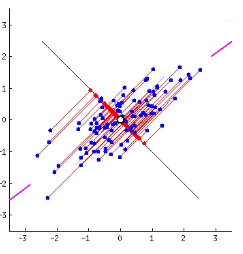  
- 데이터의 분산을 최대한 보존하면서 차원을 축소  
- 상관관계가 높은 피처들을 결합해, 상관관계가 없는 더 적은 수의 피처로 데이터를 표현  
- 원본의 고차원 데이터에서 최대 분산 방향을 찾아 상관관계를 감소시키고, 저차원에 공간에 이들을 투영하는것 → 이렇게 새로 파생된 성분 = 주성분  

***PCA주의사항**  
    1. 표준화 필수 : CA 사용 전 반드시 데이터 표준화 수행  
    2. 결측값 처리 : 결측값이 있으면 사용 불가  
    3. 해석의 어려움 : 주성분은 원본 특성들의 조합이라 직관적 해석이 어려움  
    4. 정보 손실 : 차원축소 과정에서 일부 정보가 손실  





## 3. 군집화 알고리즘  
(군집화의 2번과정인 알고리즘 선택)  

### 4가지 군집화 알고리즘 특징과 과정   

1. > **계층적 군집화(hierarchical clustering) : 가장 가까운 것부터 둘씩 차례로 합쳐 나가면서, 무엇이 언제 뭉쳤는지를 나무 모양(덴드로그램)으로 기록하는 군집화 방법.**  
Dendrogram? 가까운 두 개체 또는 군집을 점차적으로 병합해가는 과정을 시각적으로 표현한 트리 구조  

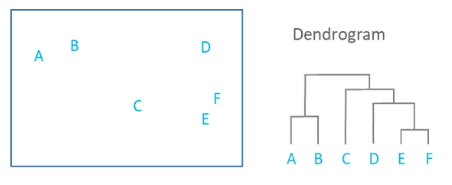  
-> Dendrogram의 수직축(높이)=두 군집이 병합될 때의 군집 간 거리(유사성)

**계층적 군집화의 특징** 
- 계층적 군집화 알고리즘은 데이터셋의 관측치를 사용해 덴드로그램 형성  
- 군집의 개수를 사전에 설정하지 않고, 클러스터링이 종료된 후에 원하는 군집의 개수를 선택 가능  
- 트리 구조를 상향식으로 구성하냐, 하향식으로 구성하냐에 따라 응집형과 분리형으로 구분  
    - 상향식 - 응집형 계층적 군집화(agglomerative hierarchical clustering, 또는 병합 클러스터링)  
    - 하향식 - 분리형 계층적 군집화(divisive hierarchical clustering, 또는 분할 클러스터링)  

**응집형/분리형 계층적 군집화**
- 응집형 클러스터링 : 각 샘플이 독립적인 클러스터로 시작. 하나만 남을 때까지 가장 가까운 클러스터를 병합  
- 분할형 클러스터링 : 전체를 포함하는 하나의 클러스터에서 시작해, 유사성이 낮은 데이터를 더 작은 클러스터로 분할  
    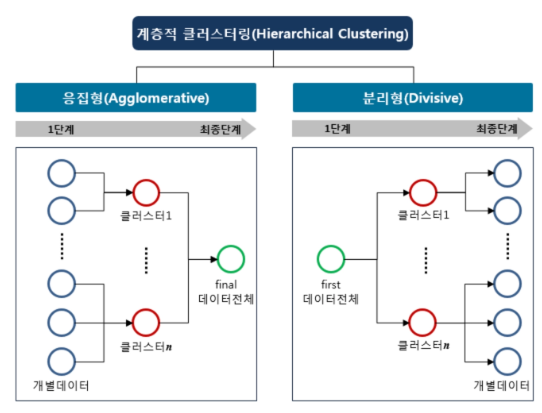  


- 응집형 군집화 과정  
    1. 거리 행렬 계산: 모든 데이터 포인트 간의 거리를 계산  
    2. 단일 클러스터 시작: 각 데이터 포인트를 개별 클러스터로 초기화  
    3. 가장 가까운 클러스터 병합: 정의된 기준에 따라 가장 가까운 두 클러스터를 병합  
    4. 거리 행렬 업데이트: 새 클러스터와 나머지 간 거리를 다시 계산  
    5. 반복: 모두 하나의 클러스터가 될 때까지 3, 4를 반복  

**6가지 연결방법**  
> 연결 방법(linkage) : 계층적 군집화에서 두 군집 간의 거리를 계산하는 방식. 어떤 방법을 고르냐에 따라 서로 다른 군집화 결과가 도출  
1. Single linkage (단일 연결법 / 최단 연결법) : 군집 A와 B 사이의 가장 가까운 두 점 간 거리로 군집 간 거리를 정의  
2. Complete linkage (완전 연결법 / 최장 연결법) : 군집 A와 B 사이의 가장 먼 두 점 간 거리로 군집 간 거리 정의  
3. Average linkage (평균 연결법) : 군집 A와 B의 모든 점 쌍 사이 거리의 평균
4. Centroid Method (중심 연결법) : 각 군집의 중심점(centroid) 간의 거리

    | 방법 | 거리 정의 | 특징 |  
    |---|---|---|   
    | Single linkage (단일 연결법 / 최단 연결법) | 군집 A와 B 사이의 가장 가까운 두 점 간 거리로 군집 간 거리를 정의 | 고립된 군집을 찾는데 중점, 이상치에 취약 |  
    | Complete linkage (완전 연결법 / 최장 연결법) | 군집 A와 B 사이의 가장 먼 두 점 간 거리로 군집 간 거리 정의 | 군집들의 내부 응집성에 중점을 둔 방법, 최단 연결법과 마찬가지로 이상치에 민감 |  
    | Average linkage (평균 연결법) | 군집 A와 B의 모든 점 쌍 사이 거리의 평균 | 모든 항목에 대한 거리 평균을 계산, 최단·최장 연결법보다 이상치에 덜 민감, 계산량이 많아질 수 있다는 단점 존재|  
    | Centroid Method (중심 연결법) | 각 군집의 중심점(centroid) 간의 거리 | 두 군집의 중심 간의 거리를 측정, 중심을 계산해야 하므로 오랜 시간 소요, 덴드로그램에서 거리 축이 줄어드는 inversion이 발생 가능 |  
    | Median (중앙 연결법) | 두 군집의 중앙값 사이의 거리 | 두 군집의 중심점 사이 산술적 중간 지점을 새로운 대표값으로 설정, 극단값에 영향을 덜 받음, 기하학적 구조를 파악하기에는 어려움 존재 |  
    | Ward's Procedure (Ward 연결법) | 군집 내 제곱합(SSE)이 가장 적게 증가하도록 병합 | 병합 후 군집 내 SSE 증가분이 최소인 것을 선택, 실무에서 가장 무난하게 쓰이는 기본값|

**덴드로그램 읽는법**  
1. 세로축 = 합쳐진 높이 = 그때의 군집 간 거리  
2. 낮게 붙은 것 = 가까운 것. A와 B는 높이 2에서 붙었으니 아주 가깝다.  
3. 긴 세로 막대 = 그만큼 멀어질 때까지 합칠 상대가 없었다는 뜻. 진짜 경계

**어디서 자를까**  
"가장 긴 세로 구간을 가로지르게" 가로선을 그어 자른다!  
why? 구간이 길다 : "이만큼 멀어지기 전까지는 아무것도 안 붙었다" *i.e.* 그 위아래는 서로 다른 세계라는 신호  
-> 이 경우 6->18로 가는 그 사이에서 자르면 2개 군집이 형성  

**계층적 군집화의 장단점**  
| 장점 | 단점 |  
|---|---|  
| k를 미리 정하지 않아도 된다 — 그려놓고 나중에 자른다 | 느리고 메모리를 많이 먹는다 — 거리 행렬 때문에 수만 건 이상은 사실상 불가 |
| 데이터의 구조 전체가 눈에 보임 — 어느 군집 안에 어떤 하위 군집이 있는지까지 볼수 있다 | 한 번 합치면 되돌릴 수 없다 — 앞에서 잘못 합쳤어도 끝까지 그대로 진행 |  
| 거리만 정의되면 어떤 유형의 데이터에도 적용 가능 | 이상치에 민감 (특히 단일·완전 연결법) |  
| 결과가 항상 동일 — 랜덤 초기화가 없어서 random_state가 필요 없다 | 자르는 높이를 결국 사람이 눈으로 정해야 한다 |

-> 실무에서는 "몇 개로 나눌지 감이 안 잡힐 때 먼저 덴드로그램을 그려보고, 거기서 얻은 k로 k-means를 돌리는" 조합을 자주 사용.

2. > **k-means : 데이터를 정해진 개수(K)의 그룹으로 나누되, 각 그룹의 중심점(centroid)과의 거리가 가장 가까운 데이터끼리 묶는 군집화 알고리즘.**  

    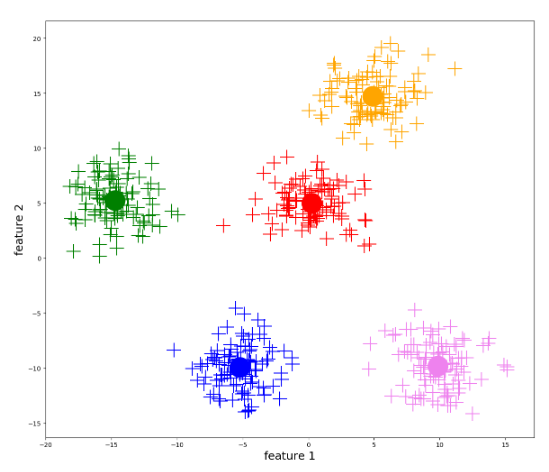  
- 군집화에서 가장 일반적으로 사용되는 알고리즘, 중심점(centroid)을 선택해 그 중심에 가장 가까운 데이터들을 묶어나가는 기법   
*군집을 중심점 하나로 대표하기 때문에 중심(평균)을 구할 수 없는 데이터에는 사용 불가*

**k-means의 주요 단계**  
1. 데이터 표본들 중에서 랜덤하게 $k$개의 중심점(centroid)을 초기 클러스터 중심으로 선택  
2. 각 표본들을 가장 가까운 중심점 $\mu^{(j)}, j \in \set{1, ..., k}$에 할당  
3. 각 클러스터에 할당된 표본들의 평균을 계산하여 중심점을 이동  
4. 클러스터 할당이 변하지 않거나 최대 반복 횟수(max_iter)에 도달할 때까지 2, 3을 반복  

**k-means의 장단점**  
| 장점 | 단점 |  
|---|---|  
| 직관적이고 구현이 쉽다 | 초기 centroid에 민감 → k-means++로 완화 |  
| 대용량 데이터에도 적용 가능하다 | 군집 수 k 결정이 어려움 → 엘보우 방법, 실루엣 계수로 탐색 |  
|| 아웃라이어에 민감 : 평균 기반이라 이상치 하나가 중심을 왜곡 |  
|| 기하학적인 모양의 군집은 파악하기 어렵다 → 길쭉하거나 초승달 모양이면 실패 |  

**엘보우 방법(Elbow Method)**  
클러스터 내 SSE를 바탕으로 그래프를 활용해 최적 클러스터 개수 k를 추정하는 방법  
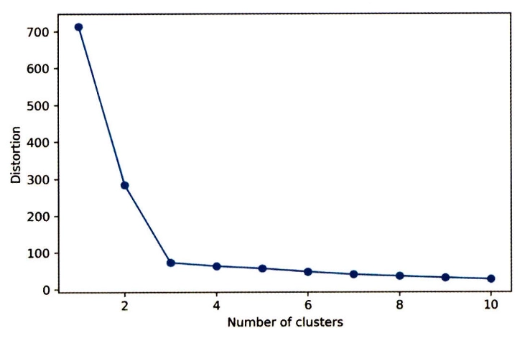  

위와 같은 상황에서 k=3인 지점에서 급격히 기울기가 변하기(팔꿈치)때문에 최적의 k이다!  
직관적이고 구현이 간단하지만, 그래프가 완만하면 팔꿈치가 어디인지 주관이 개입되거나 데이터에 따라 안보이는 경우가 발생할 수도 있다.  
-> 실루엣계수와 같이 본다


3. > **DBSCAN: 밀도가 높은 지역의 데이터를 하나의 군집으로 묶고, 밀도 기준을 만족하지 못하는 점은 군집에 포함시키지 않는 군집화 알고리즘.**    

**DBSCAN의 특징**
- 명시적으로 이상치를 지정하여 클러스터링에서 제외  
- 다른 알고리즘 대비 이상치로부터 자유로움  
- 어떤 데이터가 여러 군집의 특정 거리 내에 있으면 가장 밀도가 높은 군집과 그룹화  

**DBSCAN 알고리즘 주요 단계**  
1. 샘플 분류  
    - 핵심 샘플 (Core Point) — 반경 ε 안의 이웃이 지정된 개수(MinPts) 이상  
    - 경계 샘플 (Border Point) — ε 이내 이웃은 부족하지만, 다른 핵심 샘플의 ε 안에 있음  
    - 잡음 샘플 (Noise Point) — 위 둘 다 아닌 나머지 전부  

    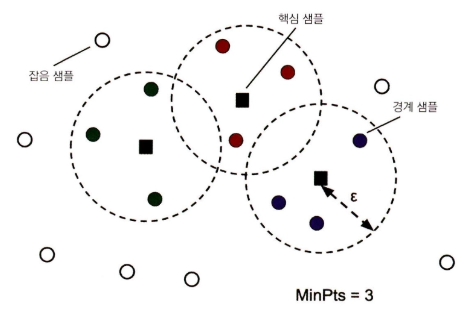  

**DBSCAN의 장단점**  
| 장점 | 단점 |  
|---|---|  
| 클러스터 모양을 원형으로 가정하지 않는다 → 임의의 기하학적 분포도 잘 처리 | eps와 min_samples 설정에 많은 영향을 받는다 (조절에 도메인 지식 필요) |
| 이상치에 민감하지 않다 : Noise를 통해 Outlier 검출이 가능 | 연산량이 많아 속도가 느리다 |  
| 모든 샘플을 클러스터에 할당하지 않음 | 밀도가 서로 다른 군집들은 잘 잡지 못한다 <br> → 밀도가 높은 곳에 집중하다 보니, 밀도가 낮은 쪽을 통째로 noise로 버린다 |  
| | 차원의 저주의 영향을 받는다 | 

4. > **GMM(Gaussian Mixture Model) : 데이터가 여러 다른 모양의 가우시안 분포로 구성되었다고 가정하고, 각 분포를 클러스터로 인식하는 군집화 방법**  
 Idea : 단일 분포로 표현하기 어려운 복잡한 확률 분포를 여러 개의 가우시안 분포를 합쳐서 표현하자  

 **GMM의 특징**  
 - 모델 기반 군집화(Model-based Clustering) — 데이터를 생성하는 통계적 모델을 가정  
 - 각 군집을 확률 분포로 간주, 전체를 여러 확률 분포의 혼합으로 모델링  
 - 데이터의 생성 메커니즘까지 모델링 가능  

 **GMM의 진행과정**  
 1. 주어진 전체 데이터셋의 분포를 확인한다  
 2. 전체 데이터셋은 서로 다른 정규분포 형태의 확률 분포 곡선으로 구성되어 있다고 가정한다  
 3. 여러개의 정규분포 곡선을 추출하고, 개별 데이터가 어떤 분포에 속하는지 결정한다. 이때, 각각의 분포가 하나의 군집이 된다.  

 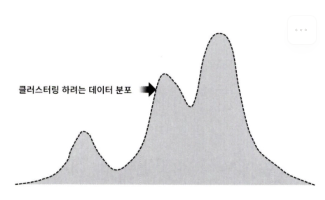 -> 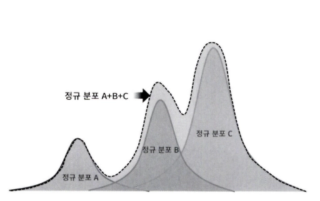 -> 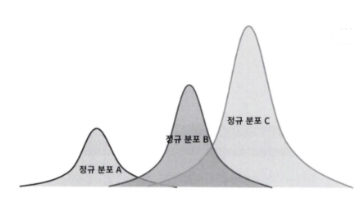     


 **K-means VS GMM**  
 | 구분 | K-means | GMM |  
 |---|---|---|  
 | 기반 | 중심 기반 | 확률 분포 기반 |  
 | 할당 방식 | 딱 하나의 군집 | 확률로 분산 할당(soft)  
 | 장점 | 원형 분포에 매우 효과적 <br> 빠른 수행 속도 | 다양한 데이터셋에 유연 <br> 길쭉하거나 겹친 분포도 준수하게 처리 |  
 |단점 | 길쭉한 분포에서 최적화 어려움 | 오래 걸림 <br> 정규분포 가정 필요 |  

 **->  K-means는 답을 주고, GMM은 답과 함께 그 답을 얼마나 믿을지를 준다**  
  
 5. 알고리즘 선택기준  
 **상황 -> 알고리즘**  

 | 상황 | 알고리즘 | Why? |  
 |---|---|---|  
 | 몇개로 나눠야할지 모름 | 계층적 군집화 | 덴드로그램을 그린 후 나중에 자를 위치를 고르면 된다 |  
 | 군집이 대체로 동글동글하고 데이터가 크다 | K-means | 빠르고 직관적. 대용량에서도 문제가 없다 |    
 | 군집 모양이 길쭉하거나 서로 겹친다 | GMM | 타원형, 중첩 구조를 확률로 처리 |   
 | 이상치를 골라내는게 목적 | DBSCAN | 이상치에 -1을 붙여 명시적으로 분리 |   
 | 군집 모양이 초승달. 소용돌이처럼 이상하다 | DBSCAN | 모양을 가정하지 않고 밀도로만 판단 |   
 | 군집마다 밀도가 제각각 | HDBSCAN | DBSCAN의 단일 밀도 기준 한계를 보완 |   
 | 경계에 걸친 데이터의 애매함까지 알고 싶다 | GMM | predict_proba로 소속확률을 반환 |   



**이럴땐 쓰지 말자**  
- k-means - 이상치가 많은 데이터. 평균기반이라 중심이 통째로 끌려간다  
- k-means - 군집크기가 심하게 불균형한 데이터. 큰 군집을 쪼개려 든다  
- 계층적 군집화 - 데이터가 수만건 이상. 거리 행렬 계신량이 감당이 안됨  
- DBSCAN - 피처가 수십 개 이상인 고차원 데이터. 차원의 저주로 밀도 개념이 무너진다  
- GMM - 데이터가 정규분포와 거리가 멀 때, 가정이 틀리면 성능이 나빠진다  
- 전부 - 스케일링하지 않은 데이터  
-> 현실적으로 하나만 고르기보단 2~3개를 돌려보고 평가지표를 비교하여 고른다  



## 4.군집화 평가 방법(실루엣 계수, 던 인덱스)  
군집화의 3번 단계(유효성 검증 part)

지도학습 모델인 회귀와 분류는 정답레이블이 존재 -> 정답 레이블과 모델의 예측값을 비교함으로써 성능평가가 가능하였다.  

But, 군집화는 비지도학습으로서 정답레이블이 없다.

그렇다면 어떻게 모델의 성능평가를 할 수 있는가?  


### 외부평가, 내부평가  
1. 외부평가(External Evaluation)  
    - 데이터에 정답 레이블이 존재하는 경우 사용  
    - 군집화 결과와 실제 레이블을 비교하여 얼마나 유사한지 평가  
    - ARI(Adjusted Rand Index)  
        - 군집화 결과와 실제 레이블간의 일치도를 측정하는 대표 지표  
        - 랜드지수(RI)를 보완하여 우연에 의한 일치 가능성을 배제한 지표  
        - 값의 범위는 -1~1 (일반적으로는 0~1)  
            - 1에 가까울수록 실제 레이블과 거의 완벽하게 일치  
            - 0에 가까울수록 무작위와 유사   

2. 내부 평가 (Internal Evaluation)  
    - 정답 레이블이 없는 경우 사용(일반적인 군집화의 케이스)  
    - 군집 내부 응집도(cohesin)와 군집간 분리도(separation)를 기반으로 품질을 정량화  
        -> 데이터 자체의 구조를 기반으로 판단  
    - 알고리즘별 내부 지표 : k-means는 SSE최소화, GMM은 로그 우도 최대화  
    - 범용 지표 : 실루엣계수, 던 지수  


### 살루엣 계수  
> **실루엣 계수**(Silhouette coefficient) : 클러스터 내 샘플들이 얼마나 조밀하게 모여 있는지를 측정하는 도구. 이를 통해 군집의 품질을 확인할 수 있다.  

**실루엣 계수 계산**  
$s^{(i)} = \frac{b^{(i)}-a^{(i)}}{max \set{b^{(i)}, a^{(i)}}}$   
1. 샘플 $\mathbf{x}^{(i)}$와 동일한 클러스터 내 다른 포인트들과의 평균 거리 -> 응집도 $a^{(i)}$  
2. 샘플 $\mathbf{x}^{(i)}$와 가장 가까운 다른 클러스터의 샘플들과의 평균 거리 -> 분리도 $b^{(i)}$  
3. 분리도에서 응집도를 뺀 값을 둘 중 큰 값으로 나눔  


### 실루엣 계수 해석  
실루엣 계수는 -1 ~ 1 사이의 값을 가짐  

| 조건 | 계수 값 | 의미 | 평가 |  
|---|---|---|---|  
| 분리도 > 응집도 | 1에 가까움 | 자신의 클러스터에 잘 속해 있고, 다른 클러스터와는 멀리 떨어져 있음 | 군집화가 잘 됨 |  
| 분리도 = 응집도 | 0에 가까움 | 클러스터 경계에 위치해 군집간 거리가 모호 | 분리가 명확하지 않음 |  
| 분리도 < 응집도 | -1에 가까움 | 잘못된 클러스터에 할당되어 군집이 섞여 있는 상태 | 군집화가 잘못됨 |   
-> 실루엣 계수가 0.5 이상이면 쓸만하고, 0.7 이상이면 잘됐다고 해석한다  

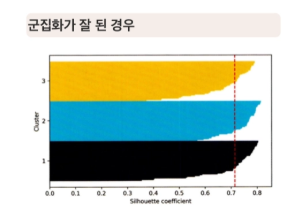  
- 실루엣 계수의 값 분포가 고르고, 평균 실루엣 계수가 0.7 이상 -> 군집화가 잘 이루어짐  

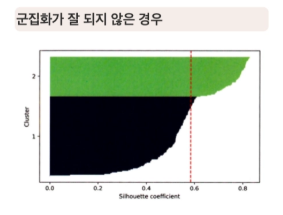  
- 실루엣 계수의 값 분포가 불균형하고, 1번 클러스터의 경우 많은 데이터 포인트들의 값이 낮은 값을 보인다 -> 군집 결과가 나쁘거나, 적어도 최적은 아님을 의미  

- 각 군집은 서로 다른색으로 표현되며, 개별 실루엣 계수를 시각화  
- 빨간 점선은 전체 평균 실루엣 계수  
- 각 군집의 분포가 고른지 여부 역시 성능평가의 기준  

### Dunn Index  
> **Dunn Index** : 클러스터간 최소거리(분리도)와 클러스터 내 최대 거리(응집도)의 비율로 클러스터링 품질을 평가하는 지표  
$\text{Dunn Index} = \frac{\min\limits_{i \neq j} d(C_i, C_j)}{\max \limits_{1 \le k \le K} \delta(C_k)}$

- $d(C_i, C_j)$ : 클러스터 $C_i$와 $C_j$사이의 거리(분리도)  
- $\delta(C_k)$ : 클러스터 $C_k$안에서 가장 멀리 떨어진 두 점간의 거리(응집도)  

**Dunn Index 해석**  
- 값이 클수록 좋은 군집화 -> 군집 간 거리는 크고(분리도$\uparrow$), 군집 내부 거리는 작을수록(응집도$\uparrow$) 좋음  
- 0 이상의 값을 가지며 상한은 없음  
- 실루엣 계수와 함께 종합적으로 판단하는것을 권장  

**Dunn Index의 한계**  
- 군집 수가 많아질수록 계산 비용이 증가  
- 극단적인 값(가장 멀리 떨어진 포인트, 가장 가까운 군집)에 큰 영향을 받음  
- 이상치에 민감하게 반응하여 수치가 급격히 떨어질 수 있음  

피처 선택 -> 알고리즘 선택 -> 유효성 검증 -> 결과 해석 과정을 반복하여 피쳐 재설정, 알고리즘 재설정 등을 통해 모델을 변화시키며 평가지표를 높이는것이 우리의 목표  

## 정리  

1. 군집화는 정답이 없는 데이터에서 구조를 찾는 비지도 학습 : 목표(응집도 $\uparrow$, 분리도 $\uparrow$)  
2. 거리 기반이므로 스케일링은 예외 없이 필수  
3. 알고리즘은 데이터 모양과 목적이 결정. 모른다면? 계층적으로 k를 보고, k-means로 돌리고, 평가로 비교  
4. 실루엣계수는 평균뿐 아니라 분포까지 본다  
5. 지표는 후보를 좁힐뿐, 최종 결정은 해석이 한다. 군집에 이름을 붙일 수 없다면 잘못 나눈 것   

**알고리즘 정리**
| 알고리즘 | 묶는 기준 | k 지정 | 이상치 | 한줄 요약 |  
|---|---|---|---|---|  
| 계층적 | 거리로 병합 | X 나중에 | 민감 | 덴드로그램으로 구조를 보고 k를 결정 |  
| k-mwans | 중심점에서의 거리 | O 필수 | 민감 | 빠르고 무난한 기본값. 원형 가정 |    
| DBSCAN | 밀도 | X 불필요 | 따로 분리 | 모양을 안 가리고, 이상치를 골라낸다 |    
| GMM | 확률분포 | O 필수 | 민감 | 확률로 답한다. 겹치고 길쭉해도 OK |  

**용어 정리**

| 용어 | 뜻 |  
|---|---|  
| 응집도(cohesin) | 같은 군집 안의 데이터끼리 얼마나 가까운가 |  
| 분리도(separation) |  서로 다른 군집끼리 얼마나 멀리 떨어져 있는가 | 
| 센트로이드(centroid) | 군집의 중심점. k-means가 이걸 옮겨가며 학습 |  
| SSE | 군집 내 제곱 오차합, 작을수록 조밀함 |  
| 덴드로그램 | 계층적 군집화의 병합 과정을 그린 트리 |  
| 차원의 저주 | 챠원이 높아질수록 모든 점이 비슷하게 멀어져 거리가 무의미해지는 현상 |  
| 실루엣 계수 | (분리도 - 응집도) / 둘중 큰 값. -1 ~ 1


